In [96]:
# visualize wandb logs

import wandb
import matplotlib.pyplot as plt
import numpy as np

username = "jedelm23-princeton-university"
project_name = "hhmm_scaling"


# useful functions; 

def average_over_seeds(data):
    # average val and train losses over different seeds for each max_iters
    unique_max_iters = np.unique([data[name].item()['max_iters'] for name in data.files])
    avg_data = {}
    for max_iter in unique_max_iters:
        val_losses = []
        train_losses = []
        steps = None
        for name in data.files:
            item = data[name].item()
            if item['max_iters'] == max_iter:
                val_losses.append(item['val_loss'])
                train_losses.append(item['train_loss'])
                steps = item['step']
        val_losses = np.array(val_losses)
        mean_val_loss = np.mean(val_losses, axis=0)
        train_losses = np.array(train_losses)
        mean_train_loss = np.mean(train_losses, axis=0)
        avg_data[max_iter] = {
            'mean_val_loss': mean_val_loss,
            'mean_train_loss': mean_train_loss,
            'steps': steps
        }
    return avg_data

In [153]:
# read in wandb logs from a specific run

#name_base = 'hhmm-12-2-1M' 
#name_base = 'hhmm-12-2-1M-1768166258'
#name_base = 'hhmm-6-4-10M-se-1768240551'
#name_base = 'hhmm-6-4-1M-1768349382' # 6,4,1M epoch scaling, 60k parameter tiny model
#name_base = 'hhmm-6-4-1M-1768351220' #6,4, 10M 60k parameter tiny model
#name_base = 'hhmm-6-4-100k-1768352736' # 6,4,100k 60k parameter tiny model
#name_base = 'hhmm-11-2-10M-1768360629' # 11,2,10M 60k parameter model
name_base = 'hhmm-11-2-10M-1768362704' # 11,2,10M 12.85M parameter model


def read_wnadb(name_base):
    api = wandb.Api()
    runs = api.runs(f"{username}/{project_name}")

    all_histories = []
    data = {}

    for run in runs: 
        if not run.name.startswith(name_base):
            continue
        history = run.history()
        history['run_name'] = run.name
        history['run_id'] = run.id
        all_histories.append(history)
        # save everything in a dictionary of dictionaries
        data[run.name] = {
            'train_loss': history['train/loss'].to_numpy(),
            'val_loss': history['val/loss'].to_numpy(),
            'step': history['_step'].to_numpy(),
            'max_iters': run.config['max_iters'],
            'seed': run.config.get('seed', 1337)
        }
    
    print(len(all_histories), "runs found.")
    return data
    

    
# save data to a npz file
data = read_wnadb(name_base)
np.savez(f'run_losses/{name_base}_logs.npz', **data)

20 runs found.


# Read in a dataset: subtract off minimum theoretical loss

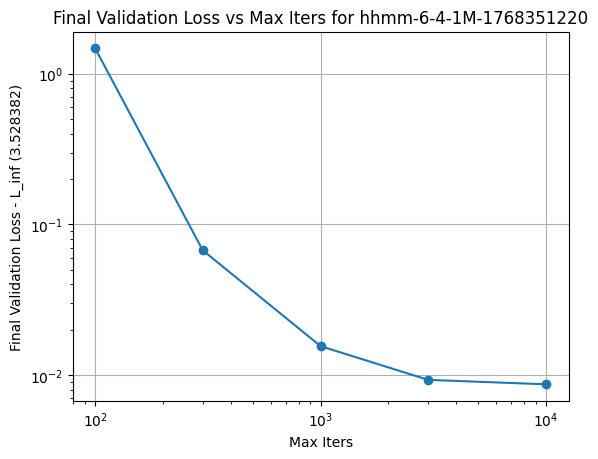

In [145]:
# read in from npz
#fname = 'hhmm-12-2-1M-1768103548' # 12,2,1M
#fname = 'hhmm-12-2-1M-1768166258' # 6,4,1M
#fname = 'hhmm-6-4-10M-se-1768240551' # 6,4,10M
#fname = 'hhmm-6-4-1M-1768349382' # 6,4,1M epoch scaling, 60k parameter tiny model
fname = 'hhmm-6-4-1M-1768351220' #6,4, 10M 60k parameter tiny model



#min_theoretical_loss = 2.1469 # hhmm 12,2
min_theoretical_loss = 3.528382 # hhmm 6,4


data = np.load(f'run_losses/{fname}_logs.npz', allow_pickle=True)

# average over seeds for each max_iters
avg_data = average_over_seeds(data)

# subtract off minimum theoretical loss
for max_iter in avg_data.keys():
    avg_data[max_iter]['mean_val_loss'] -= min_theoretical_loss
    avg_data[max_iter]['mean_train_loss'] -= min_theoretical_loss
    
# plot final validation loss between different max iters
final_val_losses = []
max_iters_list = sorted(avg_data.keys())
for max_iter in max_iters_list:
    final_val_losses.append(avg_data[max_iter]['mean_val_loss'][-1])
        
plt.figure()
plt.plot(max_iters_list, final_val_losses, marker='o')
plt.xlabel('Max Iters')
plt.ylabel(f'Final Validation Loss - L_inf ({min_theoretical_loss})')
# include fname in title
plt.title(f'Final Validation Loss vs Max Iters for {fname}')
plt.xscale('log')
plt.yscale('log')
plt.grid(True)

# Read in two datasets, compare

In [176]:
# read in saved npz file
#name1 = 'hhmm-6-4-10M-se-1768240551' # 6,4,10M 29M parameter model, big
name1 = 'hhmm-12-2-1M-1768166258' # 6,4,1M, 29M parameter model
#name1 = 'hhmm-6-4-100k-1768352736' # 6,4,100k 60k parameter tiny model
#name1 = 'hhmm-11-2-10M-1768360629' # 11,2,10M 60k parameter model
#name2 = 'hhmm-6-4-1M-1768351220' #6,4, 10M 60k parameter tiny model

name2 = 'hhmm-11-2-10M-1768362704' # 11,2,10M 12.85M parameter model

label1 = '(6,4,1M: 29M params)'
#label1 = '(6,4,100k: 60k params)'
#label1 = '(11,2,10M: 60k params)'
#label2 = '(6,4,10M: 60k params)'
label2 = '(11,2,10M: 12.85M params)'

data1 = np.load(f'run_losses/{name1}_logs.npz', allow_pickle=True)
data2 = np.load(f'run_losses/{name2}_logs.npz', allow_pickle=True)

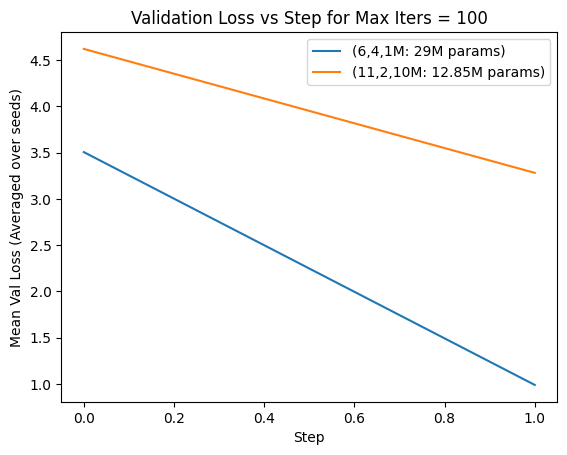

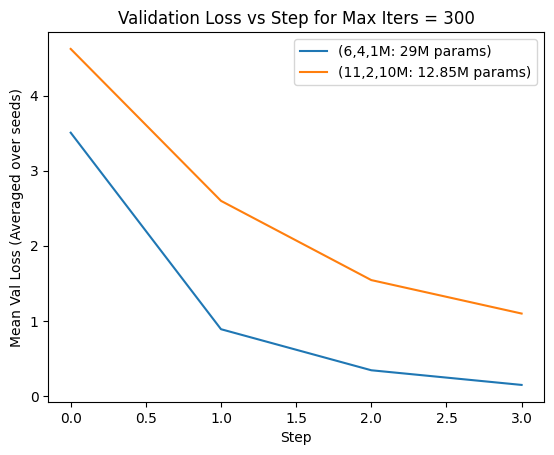

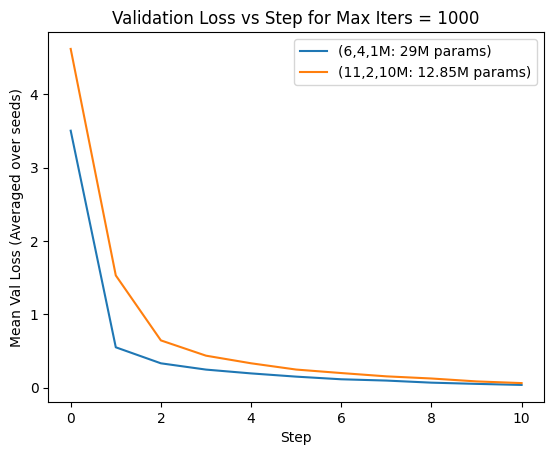

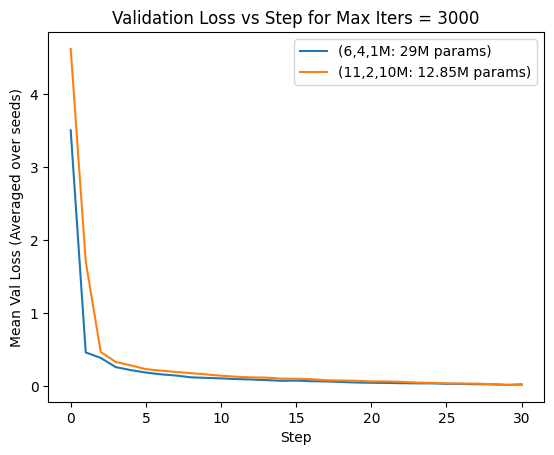

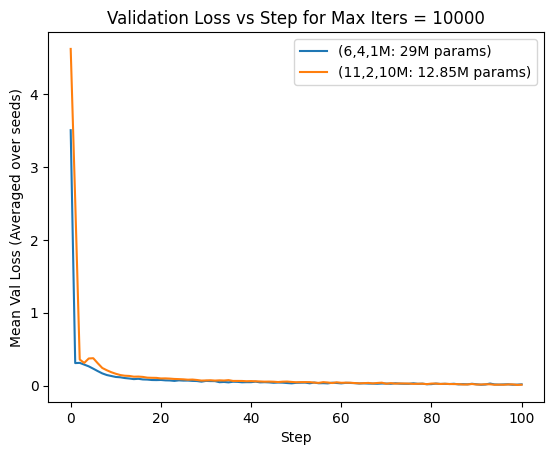

In [177]:
# average runs over seeds for both datasets

avg_data1 = average_over_seeds(data1)
avg_data2 = average_over_seeds(data2)

# subtract off minimum theoretical loss
L_inf_2 = 2.146797006  # hhmm, 11, 2
#L_inf_2 = 3.528382 # hhmm 6,4
L_inf_1 = 3.528382156 # hhmm g,4 (more precise)


for max_iter in avg_data1.keys():
    avg_data1[max_iter]['mean_val_loss'] -= L_inf_1
    avg_data2[max_iter]['mean_val_loss'] -= L_inf_2
    avg_data1[max_iter]['mean_train_loss'] -= L_inf_1
    avg_data2[max_iter]['mean_train_loss'] -= L_inf_2

# plot comparison
for max_iter in avg_data1.keys():
    plt.figure()
    plt.plot(avg_data1[max_iter]['steps'], avg_data1[max_iter]['mean_val_loss'], label=label1)
    plt.plot(avg_data2[max_iter]['steps'], avg_data2[max_iter]['mean_val_loss'], label=label2)
    plt.xlabel('Step')
    plt.ylabel('Mean Val Loss (Averaged over seeds)')
    plt.title(f'Validation Loss vs Step for Max Iters = {max_iter}')
    plt.legend()
    #plt.yscale('log')
    #plt.xscale('log')
    #plt.grid(True)


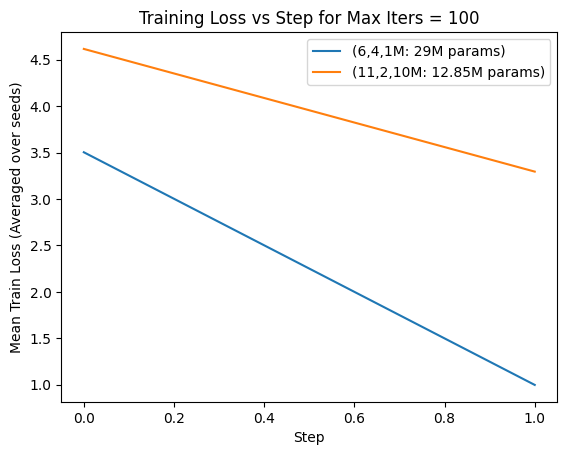

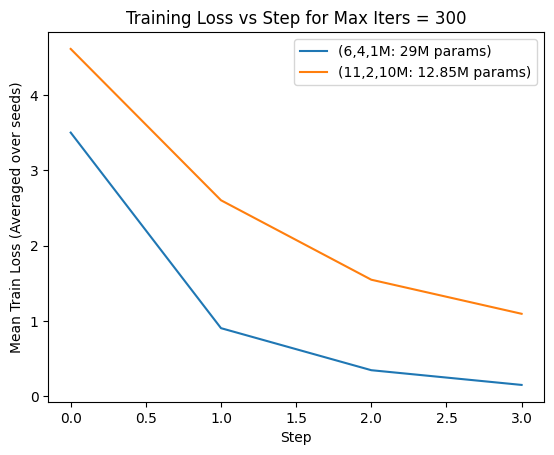

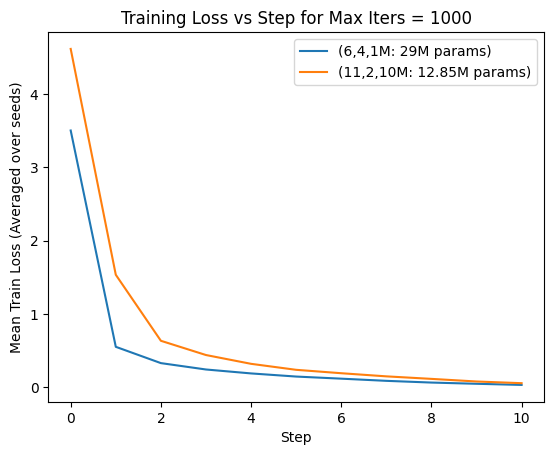

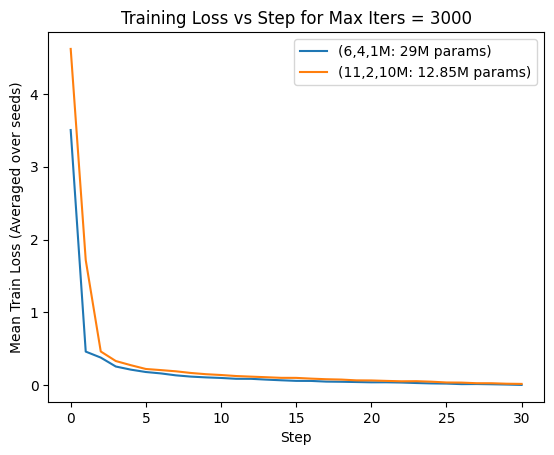

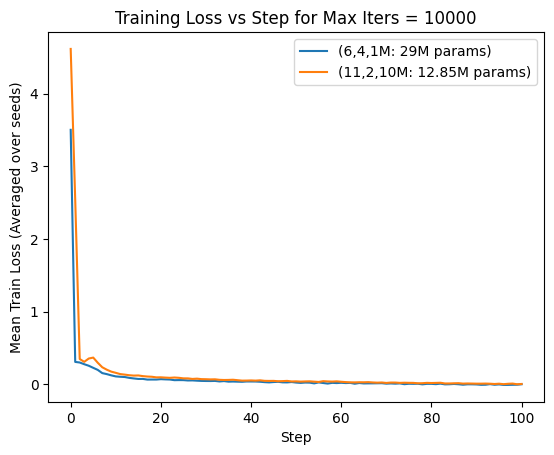

In [178]:
# plot comparison for training loss
for max_iter in avg_data1.keys():
    plt.figure()
    plt.plot(avg_data1[max_iter]['steps'], avg_data1[max_iter]['mean_train_loss'], label=label1)
    plt.plot(avg_data2[max_iter]['steps'], avg_data2[max_iter]['mean_train_loss'], label=label2)
    plt.xlabel('Step')
    plt.ylabel('Mean Train Loss (Averaged over seeds)')
    plt.title(f'Training Loss vs Step for Max Iters = {max_iter}')
    plt.legend()

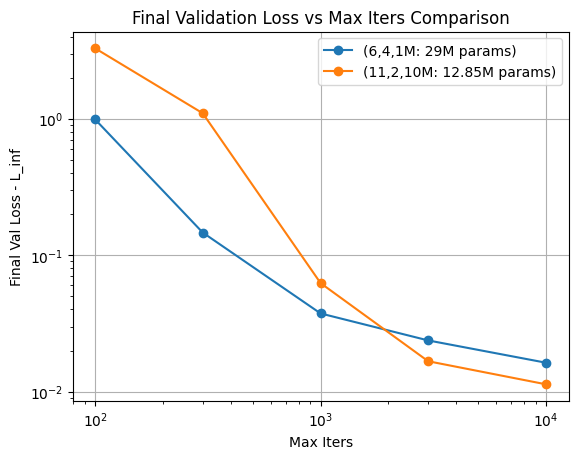

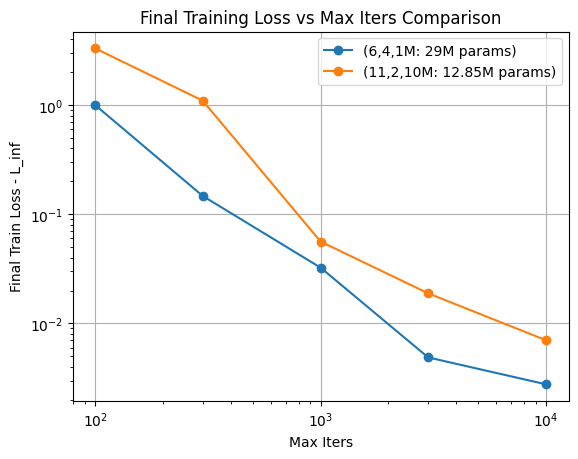

In [179]:
# get final val and train losses
final_val_losses1 = {}
final_train_losses1 = {}
final_val_losses2 = {}
final_train_losses2 = {}
for max_iter in avg_data1.keys():
    final_val_losses1[max_iter] = avg_data1[max_iter]['mean_val_loss'][-1]
    final_train_losses1[max_iter] = avg_data1[max_iter]['mean_train_loss'][-1]
    final_val_losses2[max_iter] = avg_data2[max_iter]['mean_val_loss'][-1]
    final_train_losses2[max_iter] = avg_data2[max_iter]['mean_train_loss'][-1]
    
# plot final val losses comparison
max_iters_list = sorted(avg_data1.keys())
final_vals1 = [final_val_losses1[max_iter] for max_iter in max_iters_list]
final_vals2 = [final_val_losses2[max_iter] for max_iter in max_iters_list]
plt.figure()
plt.plot(max_iters_list, final_vals1, marker='o', label=label1)
plt.plot(max_iters_list, final_vals2, marker='o', label=label2)
plt.xlabel('Max Iters')
plt.ylabel('Final Val Loss - L_inf')
plt.title('Final Validation Loss vs Max Iters Comparison')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True)

# plot final train losses comparison
final_trains1 = [final_train_losses1[max_iter] for max_iter in max_iters_list]
final_trains2 = [final_train_losses2[max_iter] for max_iter in max_iters_list]
plt.figure()
plt.plot(max_iters_list, final_trains1, marker='o', label=label1)
plt.plot(max_iters_list, final_trains2, marker='o', label=label2)
plt.xlabel('Max Iters')
plt.ylabel('Final Train Loss - L_inf')
plt.title('Final Training Loss vs Max Iters Comparison')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True)

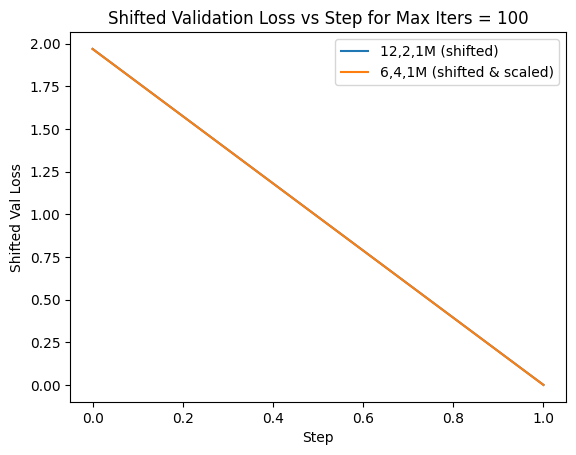

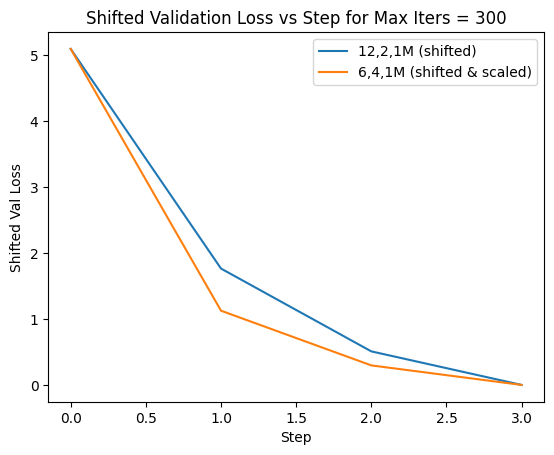

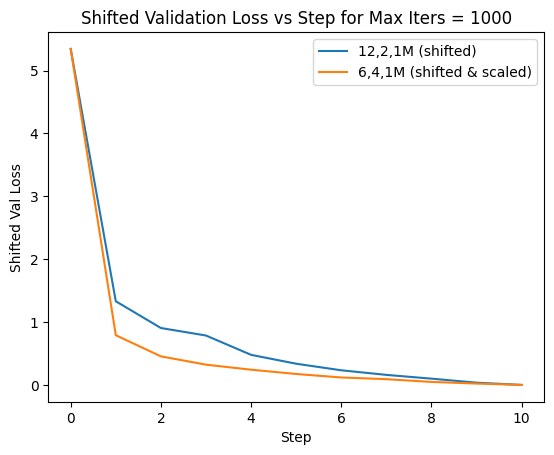

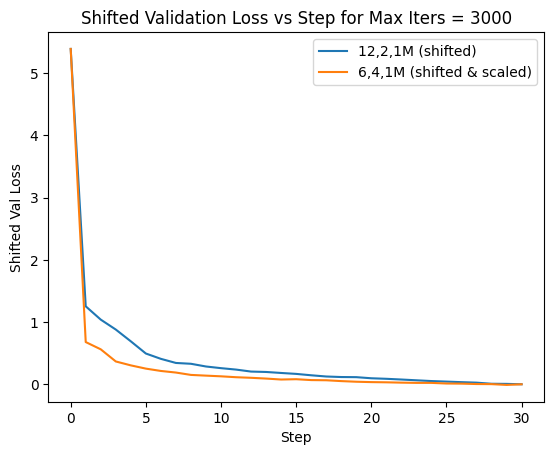

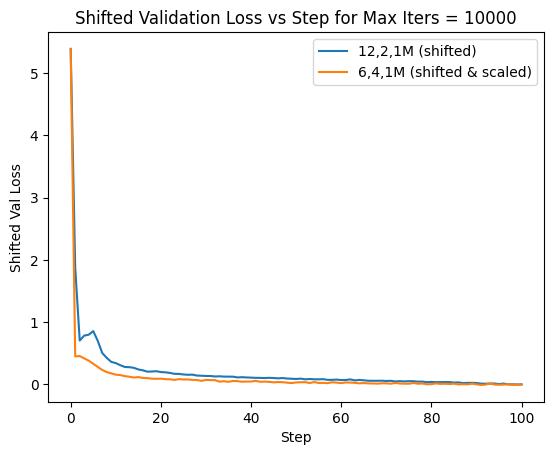

In [ ]:
# DEPRECIATED: now subtract off the final loss asymptotes, and scale so that the first val losses are the same


for max_iter in avg_data1.keys():
    val_loss1 = avg_data1[max_iter]['mean_val_loss']
    val_loss2 = avg_data2[max_iter]['mean_val_loss']
    steps = avg_data1[max_iter]['steps']
    
    # subtract off final loss asymptotes
    L_inf1 = val_loss1[-1]
    L_inf2 = val_loss2[-1]
    shifted_loss1 = val_loss1 - L_inf1
    shifted_loss2 = val_loss2 - L_inf2
    
    # scale so that the first val losses are the same
    scale_factor = shifted_loss1[0] / shifted_loss2[0]
    scaled_loss2 = shifted_loss2 * scale_factor
    
    plt.figure()
    plt.plot(steps, shifted_loss1, label='12,2,1M (shifted)')
    plt.plot(steps, scaled_loss2, label='6,4,1M (shifted & scaled)')
    plt.xlabel('Step')
    plt.ylabel('Shifted Val Loss')
    plt.title(f'Shifted Validation Loss vs Step for Max Iters = {max_iter}')
    plt.legend()

# Compare epoch scaling vs dataset size scaling

In [ ]:
# read in saved npz files

# epoch scaling
fname_epoch = 'hhmm-12-2-1M-1768166258' # 6,4,1M
data_epoch = np.load(f'run_losses/{fname_epoch}_logs.npz', allow_pickle=True)

# dataset size scaling
fname_datasize = 'hhmm-6-4-10M-se-1768240551' # 6,4,10M
data_datasize = np.load(f'run_losses/{fname_datasize}_logs.npz', allow_pickle=True)

# average over seeds for both datasets
avg_data_epoch = average_over_seeds(data_epoch)
avg_data_datasize = average_over_seeds(data_datasize)

# subtract off minimum theoretical loss (from training and val)
L_inf = 3.528382 # hhmm 6,4


# subtract
for max_iter in avg_data_epoch.keys():
    avg_data_epoch[max_iter]['mean_val_loss'] -= L_inf
    avg_data_datasize[max_iter]['mean_val_loss'] -= L_inf


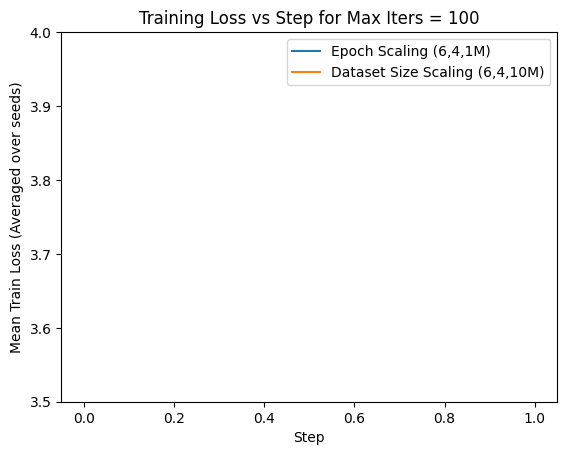

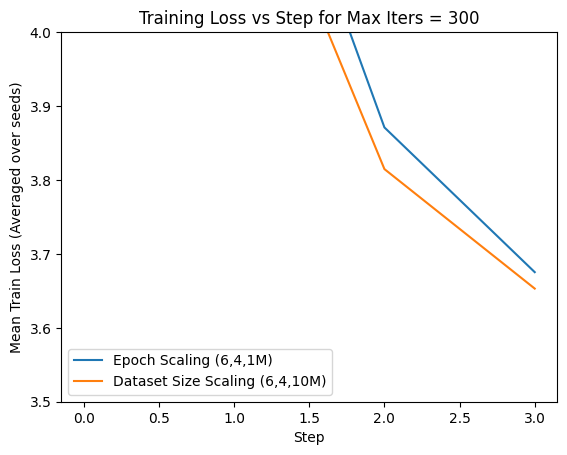

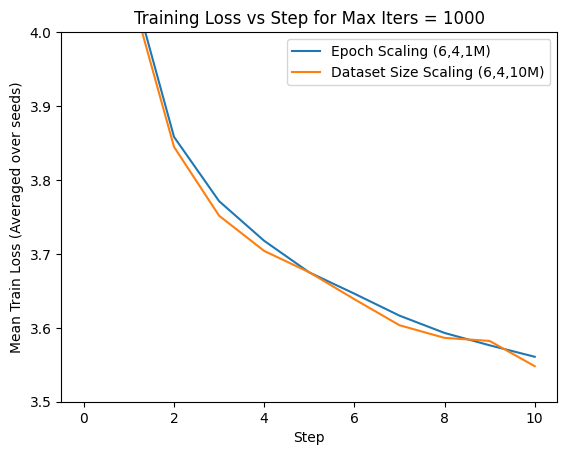

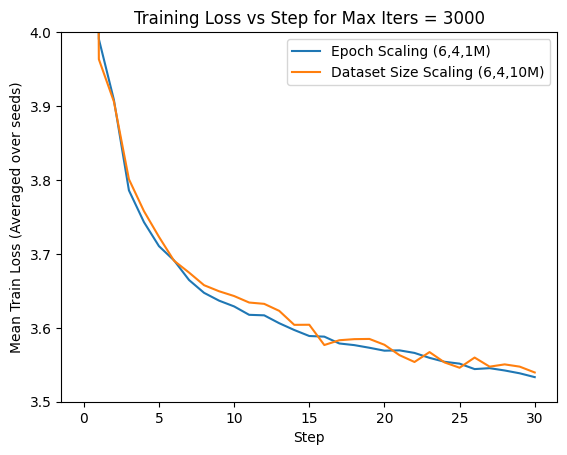

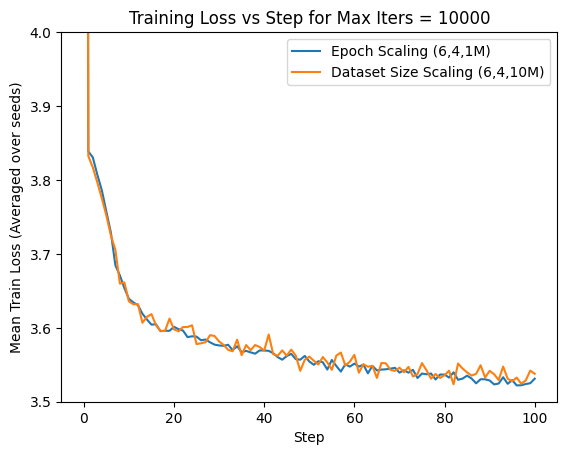

In [87]:
# plot training loss comparison
for max_iter in avg_data_epoch.keys():
    plt.figure()
    plt.plot(avg_data_epoch[max_iter]['steps'], avg_data_epoch[max_iter]['mean_train_loss'], label='Epoch Scaling (6,4,1M)')
    plt.plot(avg_data_datasize[max_iter]['steps'], avg_data_datasize[max_iter]['mean_train_loss'], label='Dataset Size Scaling (6,4,10M)')
    plt.xlabel('Step')
    plt.ylabel('Mean Train Loss (Averaged over seeds)')
    plt.title(f'Training Loss vs Step for Max Iters = {max_iter}')
    plt.ylim(3.5,4)
    plt.legend()

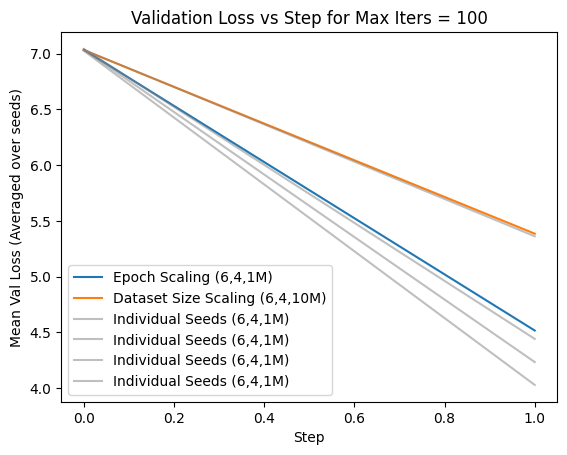

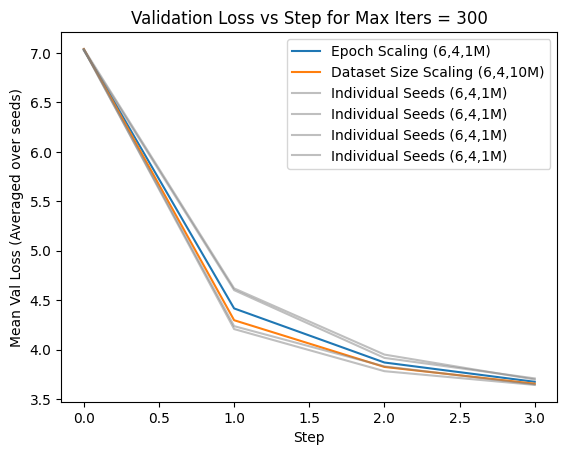

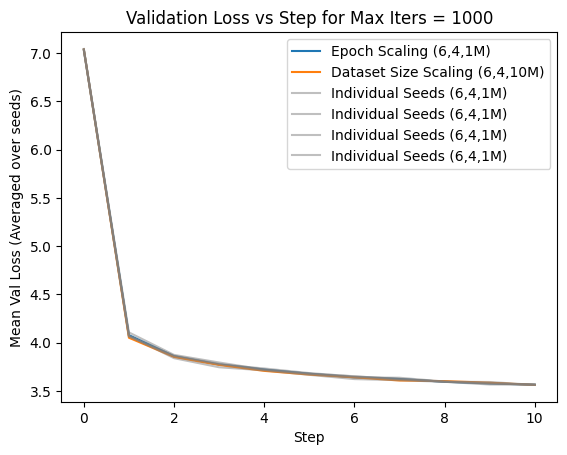

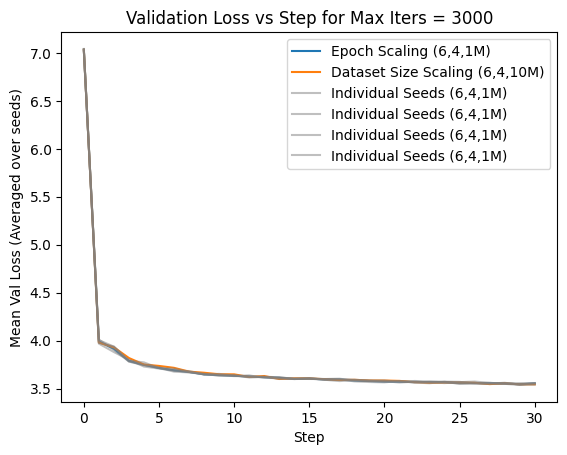

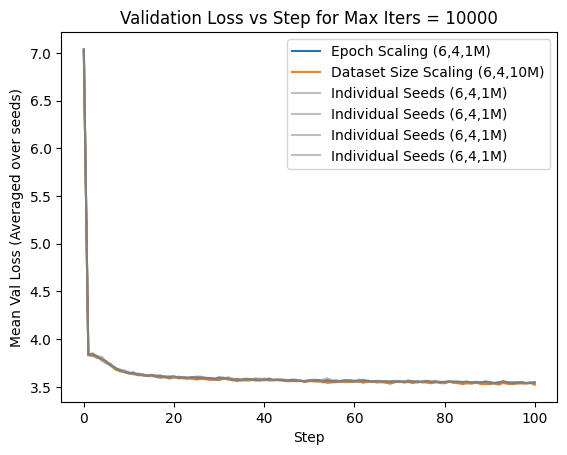

In [103]:
# plot val loss comparison
for max_iter in avg_data_epoch.keys():
    plt.figure()
    plt.plot(avg_data_epoch[max_iter]['steps'], avg_data_epoch[max_iter]['mean_val_loss'], label='Epoch Scaling (6,4,1M)')
    plt.plot(avg_data_datasize[max_iter]['steps'], avg_data_datasize[max_iter]['mean_val_loss'], label='Dataset Size Scaling (6,4,10M)')
    # plot all seeds for the epoch scaling case
    for name in data_epoch.files:
        item = data_epoch[name].item()
        if item['max_iters'] == max_iter:
            plt.plot(item['step'], item['val_loss'], color='gray', alpha=0.5, label='Individual Seeds (6,4,1M)')
    plt.xlabel('Step')
    plt.ylabel('Mean Val Loss (Averaged over seeds)')
    plt.title(f'Validation Loss vs Step for Max Iters = {max_iter}')
    plt.legend()
    #plt.ylim(3.5,4)
